In [ ]:
import numpy as np

n = 200
A = np.random.rand(n, n)
B = np.random.rand(n, n)

In [ ]:
import time

def serial_multiply(A, B):
    n = A.shape[0]
    C = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i, j] += A[i, k] * B[k, j]

    return C

start = time.time()
C_serial = serial_multiply(A, B)
serial_time = time.time() - start

print("Serial Time:", serial_time)

Serial Time: 8.098305225372314


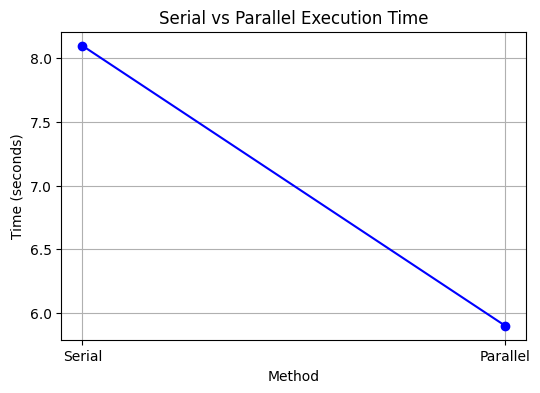

In [ ]:
import matplotlib.pyplot as plt

methods = ['Serial', 'Parallel']
times = [serial_time, parallel_time]

plt.figure(figsize=(6, 4))
plt.plot(methods, times, marker='o', linestyle='-', color='blue')
plt.title('Serial vs Parallel Execution Time')
plt.xlabel('Method')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.show()

In [ ]:
from multiprocessing import Pool

def compute_row(i):
    row = []
    for j in range(n):
        s = 0
        for k in range(n):
            s += A[i][k] * B[k][j]
        row.append(s)
    return row

def parallel_multiply(A, B):

    with Pool(processes=2) as p:
        result = p.map(compute_row, range(n))
    return np.array(result)

start = time.time()
C_parallel = parallel_multiply(A, B)
parallel_time = time.time() - start

print("Parallel Time:", parallel_time)

Parallel Time: 5.900457382202148


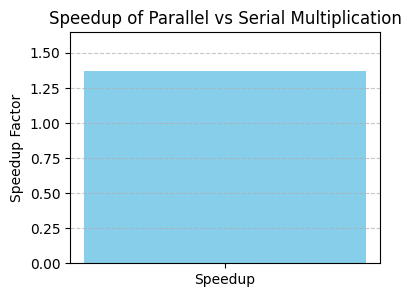

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.bar(['Speedup'], [speedup], color='skyblue')
plt.title('Speedup of Parallel vs Serial Multiplication')
plt.ylabel('Speedup Factor')
plt.ylim(0, max(speedup * 1.2, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

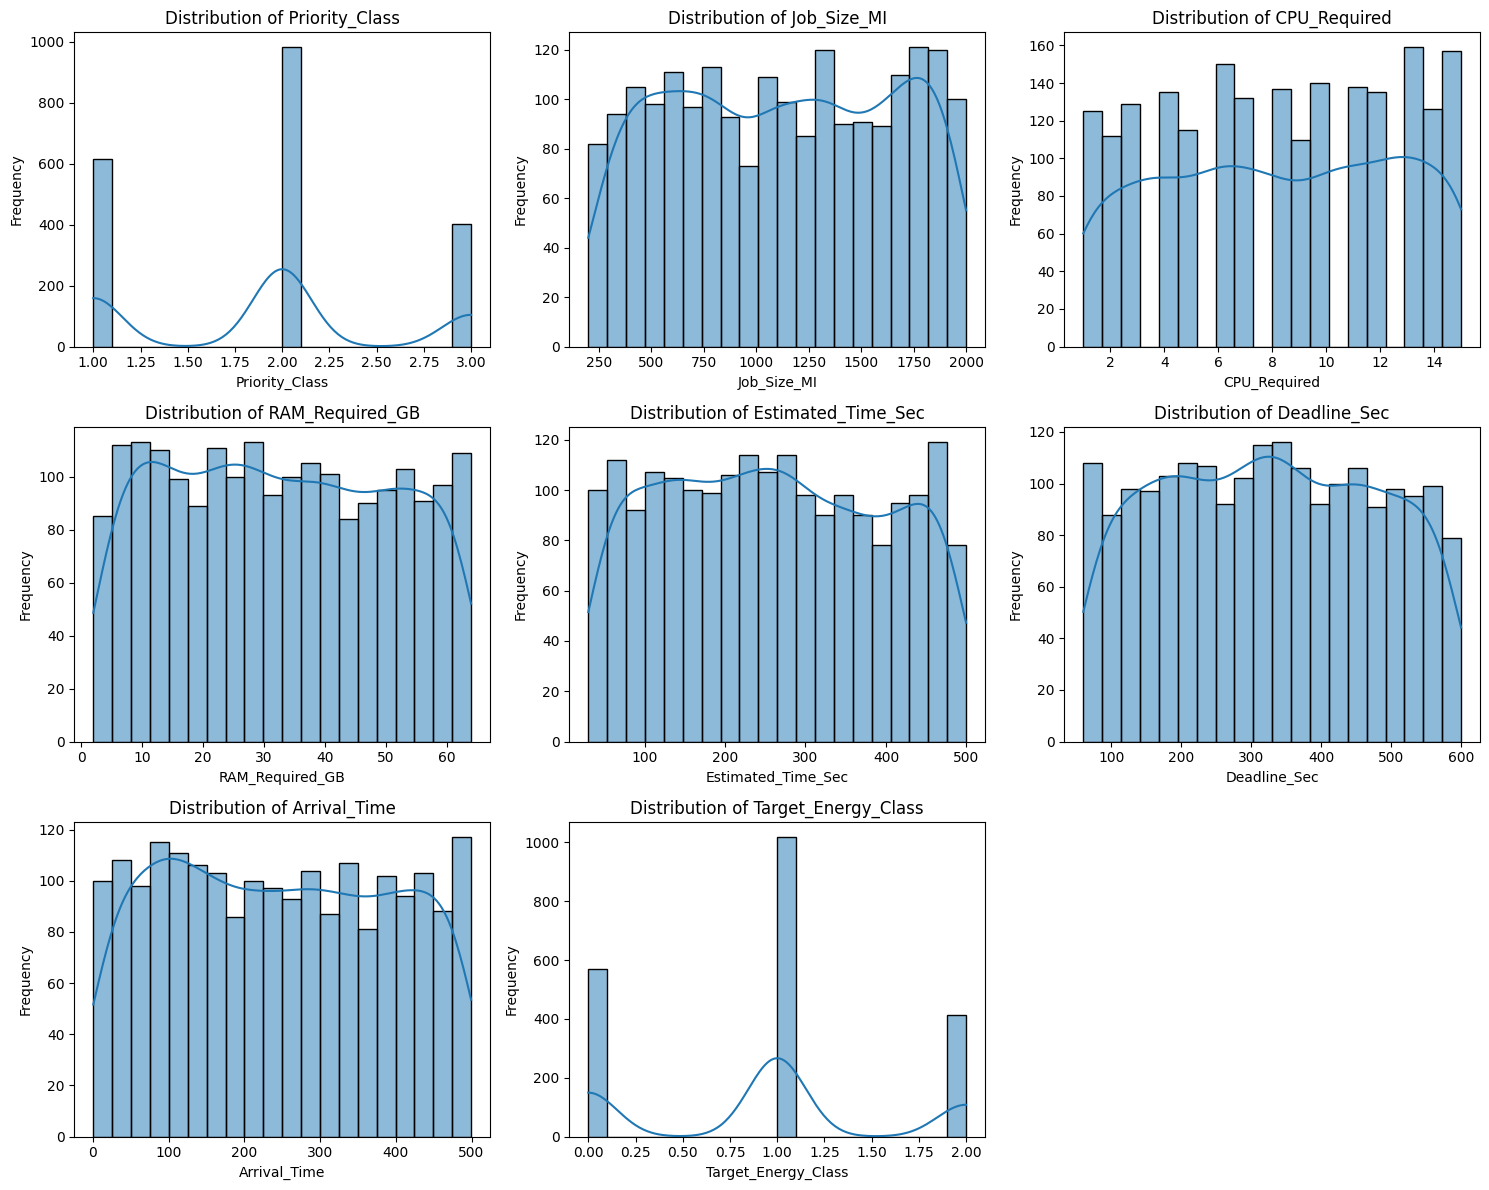

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get only numeric columns for histogram
numeric_cols = df.select_dtypes(include=['number']).columns

# Determine grid size for subplots
num_plots = len(numeric_cols)
num_cols_subplot = 3 # Number of columns in the subplot grid
num_rows_subplot = (num_plots + num_cols_subplot - 1) // num_cols_subplot # Calculate rows needed

plt.figure(figsize=(5 * num_cols_subplot, 4 * num_rows_subplot))

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows_subplot, num_cols_subplot, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
speedup = serial_time / parallel_time
print("Speedup:", speedup)

Speedup: 1.3724877074444513


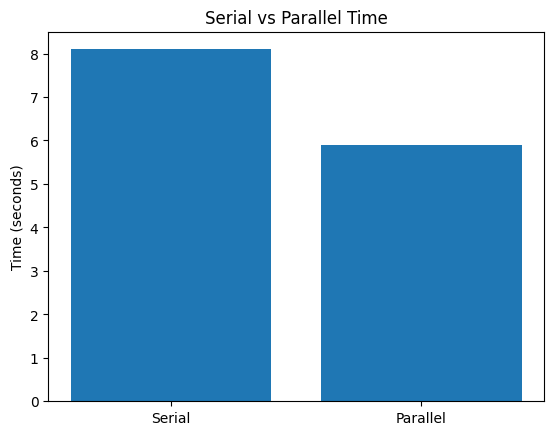

In [ ]:
import matplotlib.pyplot as plt

methods = ['Serial', 'Parallel']
times = [serial_time, parallel_time]

plt.bar(methods, times)
plt.title("Serial vs Parallel Time")
plt.ylabel("Time (seconds)")
plt.show()